Лабораторна робота 2. Запорожан 4-8


---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)


for table in tables:
    if len(table) > 150:
        df_raw = table
        break

df_raw.head()

/tmp/ipykernel_1687/4139908731.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [7]:
print("Розмір датасета:", df_raw.shape)

Розмір датасета: (222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [13]:
print("Розмір датасета:", df_raw.shape)

Розмір датасета: (222, 4)


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [14]:

df = pd.DataFrame()

df['Country'] = df_raw.iloc[:, 0]
df['IMF_2026'] = df_raw.iloc[:, 1]
df['World_Bank_2025'] = df_raw.iloc[:, 2]
df['United_Nations_2024'] = df_raw.iloc[:, 3]

df = df[df['Country'] != 'World'].copy()

df.head()

,Country,IMF_2026,World_Bank_2025,United_Nations_2024
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881


In [15]:
df.replace("—", np.nan, inplace=True)

columns_to_convert = ['IMF_2026', 'World_Bank_2025', 'United_Nations_2024']
for col in columns_to_convert:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Пропущені значення ДО заміни:")
print(df.isna().sum())

for col in columns_to_convert:
    df[col] = df[col].fillna(df[col].mean())

print("\nПропущені значення ПІСЛЯ заміни:")
print(df.isna().sum())

Пропущені значення ДО заміни:
Country                 0
IMF_2026               31
World_Bank_2025        35
United_Nations_2024     9
dtype: int64

Пропущені значення ПІСЛЯ заміни:
Country                0
IMF_2026               0
World_Bank_2025        0
United_Nations_2024    0
dtype: int64


5. Ще раз вивести датасет

In [16]:
df.head()

,Country,IMF_2026,World_Bank_2025,United_Nations_2024
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [20]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates()

Кількість дублікатів: 0


7.	Вивести описову статистику датасету describe()

In [19]:
df.describe()

,IMF_2026,World_Bank_2025,United_Nations_2024
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05
std,2.666759e+06,2.520399e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.895900e+04,1.992800e+04,8.840000e+03
50%,1.020420e+05,9.977400e+04,4.276500e+04
75%,6.614603e+05,6.260497e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [21]:
df['Diff_IMF_WB'] = abs(df['IMF_2026'] - df['World_Bank_2025'])

max_diff_index = df['Diff_IMF_WB'].idxmax()
country_max_diff = df.loc[max_diff_index, 'Country']
diff_value = df.loc[max_diff_index, 'Diff_IMF_WB']

print(f"Найбільше відрізняються показники у країни: {country_max_diff} (на {diff_value:.2f} млн $)")

Найбільше відрізняються показники у країни: United States (на 1614220.00 млн $)


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [22]:
corr_matrix = df[['IMF_2026', 'World_Bank_2025', 'United_Nations_2024']].corr()
print("Матриця кореляції:\n", corr_matrix)

Матриця кореляції:
                      IMF_2026  World_Bank_2025  United_Nations_2024
IMF_2026             1.000000         0.998639             0.997343
World_Bank_2025      0.998639         1.000000             0.997011
United_Nations_2024  0.997343         0.997011             1.000000


Обчислити середнє значення за стовпцями

In [23]:
print(df[['IMF_2026', 'World_Bank_2025', 'United_Nations_2024']].mean())

IMF_2026               661460.289474
World_Bank_2025        626049.693548
United_Nations_2024    522491.207547
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [24]:
df['Std_Dev'] = df[['IMF_2026', 'World_Bank_2025', 'United_Nations_2024']].std(axis=1)

country_max_std = df.loc[df['Std_Dev'].idxmax(), 'Country']
print(f"Країна з найвищою варіативністю: {country_max_std}")

Країна з найвищою варіативністю: United States


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [25]:
for col in columns_to_convert:
    highest = df.loc[df[col].idxmax(), 'Country']
    lowest = df.loc[df[col].idxmin(), 'Country']
    print(f"{col}: Найвищий ВВП - {highest} | Найнижчий ВВП - {lowest}")

IMF_2026: Найвищий ВВП - United States | Найнижчий ВВП - Tuvalu
World_Bank_2025: Найвищий ВВП - United States | Найнижчий ВВП - Tuvalu
United_Nations_2024: Найвищий ВВП - United States | Найнижчий ВВП - Tuvalu


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

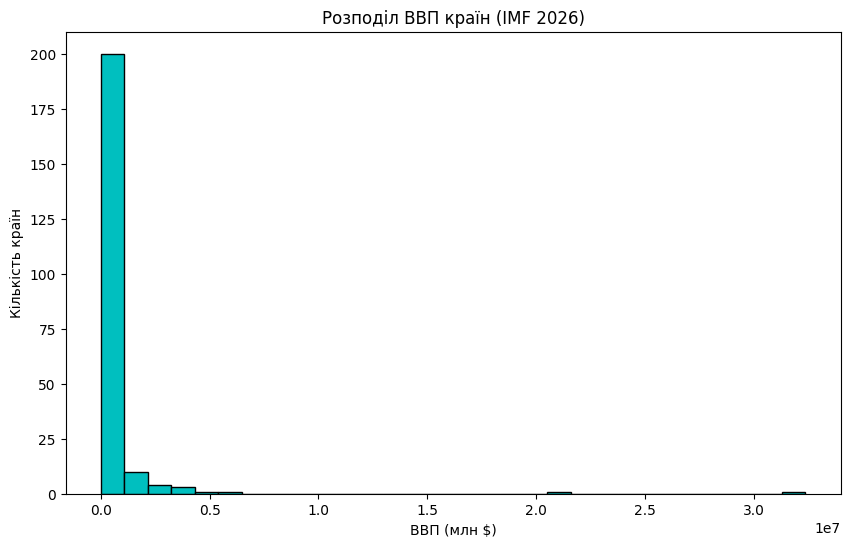

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df['IMF_2026'], bins=30, color='c', edgecolor='black')
plt.title('Розподіл ВВП країн (IMF 2026)')
plt.xlabel('ВВП (млн $)')
plt.ylabel('Кількість країн')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [28]:
df['Share_IMF_2026_%'] = (df['IMF_2026'] / df['IMF_2026'].sum()) * 100
df['Share_WB_2025_%'] = (df['World_Bank_2025'] / df['World_Bank_2025'].sum()) * 100
df['Share_UN_2024_%'] = (df['United_Nations_2024'] / df['United_Nations_2024'].sum()) * 100

df[['Country', 'Share_IMF_2026_%', 'Share_WB_2025_%', 'Share_UN_2024_%']].head()

,Country,Share_IMF_2026_%,Share_WB_2025_%,Share_UN_2024_%
1,United States,22.153042,22.239355,25.372702
2,China[n 1],14.264061,14.092559,16.232538
3,Germany,3.730166,3.650646,4.035599
4,Japan,2.995739,3.205594,3.486786
5,United Kingdom,2.917441,2.892943,3.192053


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

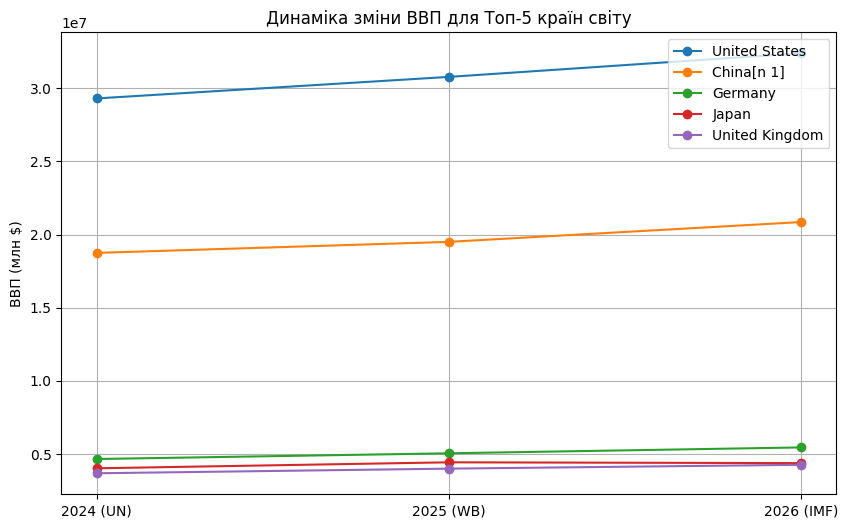

In [29]:
top_5 = df.nlargest(5, 'IMF_2026')

plt.figure(figsize=(10, 6))
for index, row in top_5.iterrows():
    plt.plot(['2024 (UN)', '2025 (WB)', '2026 (IMF)'],
             [row['United_Nations_2024'], row['World_Bank_2025'], row['IMF_2026']],
             marker='o', label=row['Country'])

plt.title('Динаміка зміни ВВП для Топ-5 країн світу')
plt.ylabel('ВВП (млн $)')
plt.legend()
plt.grid(True)
plt.show()